# Vision Transformer (ViT) – CIFAR-100 Image Classification

This notebook builds and evaluates a Vision Transformer for 100-class image classification on CIFAR-100. It uses a compact Transformer architecture designed for 32×32 images, trains with AdamW and cosine learning-rate decay, tracks validation performance, evaluates the best checkpoint on the held-out test set, and analyzes class-wise and sample-level predictions on a Google Colab NVIDIA Tesla T4 runtime.

## 1. Import Libraries and Check Runtime
Load the required libraries and verify the Python, PyTorch, CUDA, and GPU environment.

In [1]:
import os
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {__import__('torchvision').__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    torch.set_float32_matmul_precision("high")
else:
    print("GPU: CPU")


Python: 3.13.15
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
CUDA available: True
GPU: Tesla T4
CUDA version: 13.0


## 2. Configure Reproducibility and Training
Set the dataset split, model configuration, optimization settings, and output paths used throughout the notebook.

In [2]:
SEED = 42
NUM_CLASSES = 100
IMAGE_SIZE = 32
PATCH_SIZE = 4
EMBED_DIM = 256
DEPTH = 6
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1
BATCH_SIZE = 128
NUM_WORKERS = 2
EPOCHS = 60
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
VAL_SIZE = 5000
DATA_DIR = Path("/content/data")
RUN_DIR = Path("/content/vit_cifar100_runs")
CHECKPOINT_PATH = RUN_DIR / "best_model.pth"

RUN_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

g = torch.Generator().manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = pd.Series({
    "Seed": SEED,
    "Image size": IMAGE_SIZE,
    "Patch size": PATCH_SIZE,
    "Embedding dimension": EMBED_DIM,
    "Transformer depth": DEPTH,
    "Attention heads": NUM_HEADS,
    "MLP ratio": MLP_RATIO,
    "Dropout": DROPOUT,
    "Batch size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning rate": LEARNING_RATE,
    "Weight decay": WEIGHT_DECAY,
    "Label smoothing": LABEL_SMOOTHING,
    "Device": str(DEVICE)
})
print(config.to_string())


Seed                       42
Image size                 32
Patch size                  4
Embedding dimension       256
Transformer depth           6
Attention heads             8
MLP ratio                 4.0
Dropout                   0.1
Batch size                128
Epochs                     60
Learning rate          0.0003
Weight decay             0.05
Label smoothing           0.1
Device                   cuda


## 3. Load the CIFAR-100 Dataset
Download CIFAR-100 and create deterministic training and validation subsets from the original training set.

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

base_train = datasets.CIFAR100(root=DATA_DIR, train=True, download=True)
train_indices = torch.randperm(len(base_train), generator=g).tolist()
val_indices = train_indices[:VAL_SIZE]
train_indices = train_indices[VAL_SIZE:]

train_dataset = Subset(datasets.CIFAR100(root=DATA_DIR, train=True, transform=train_transform, download=False), train_indices)
val_dataset = Subset(datasets.CIFAR100(root=DATA_DIR, train=True, transform=eval_transform, download=False), val_indices)
test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, transform=eval_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

class_names = base_train.classes

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(class_names)}")


100%|██████████| 169M/169M [32:13<00:00, 87.4kB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: 100


## 4. Inspect the Dataset
Display representative CIFAR-100 training images and verify the label mapping used by the classifier.

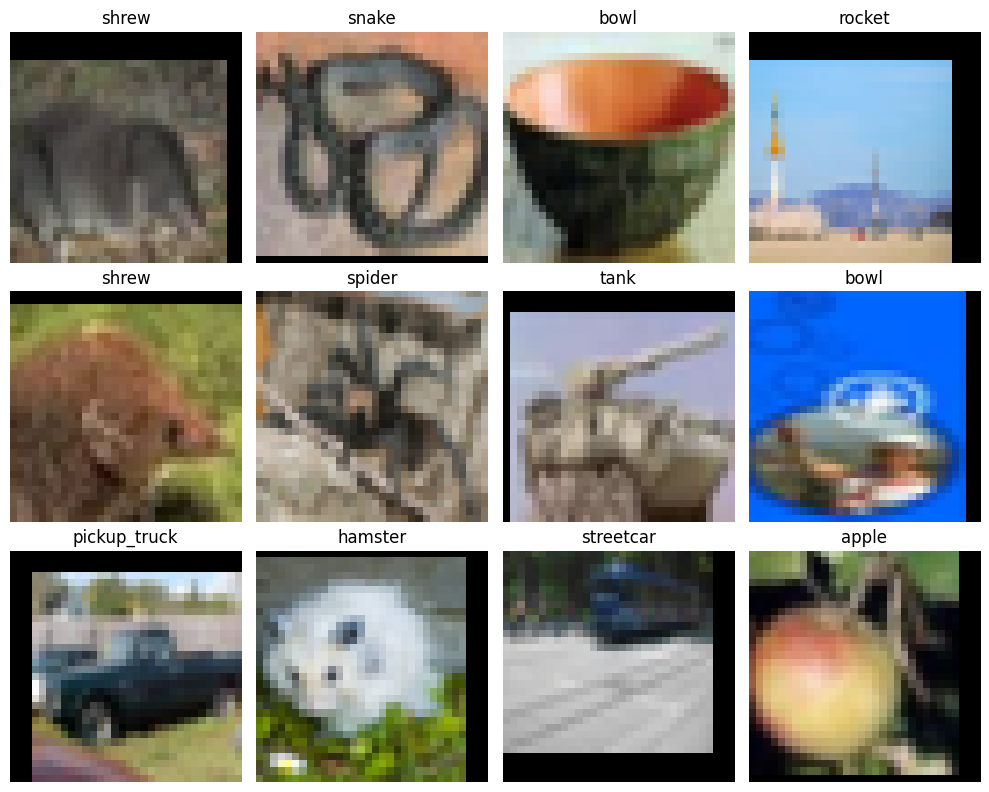

0             apple
1     aquarium_fish
2              baby
3              bear
4            beaver
5               bed
6               bee
7            beetle
8           bicycle
9            bottle
10             bowl
11              boy
12           bridge
13              bus
14        butterfly
15            camel
16              can
17           castle
18      caterpillar
19           cattle


In [4]:
images, labels = next(iter(DataLoader(train_dataset, batch_size=12, shuffle=True, num_workers=0)))
images_for_plot = images.clone()
mean = torch.tensor((0.5071, 0.4867, 0.4408)).view(3, 1, 1)
std = torch.tensor((0.2675, 0.2565, 0.2761)).view(3, 1, 1)
images_for_plot = (images_for_plot * std + mean).clamp(0, 1)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_for_plot[i].permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

print(pd.Series(class_names, index=range(NUM_CLASSES), name="class").head(20).to_string())


## 5. Build the Vision Transformer
Construct a compact ViT with 4×4 image patches, a learnable class token, positional embeddings, and stacked Transformer encoder blocks.

In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (image_size // patch_size) ** 2

    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MLPBlock(nn.Module):
    def __init__(self, embed_dim, mlp_ratio, dropout):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.network = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLPBlock(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        normalized = self.norm1(x)
        attention_output = self.attention(normalized, normalized, normalized, need_weights=False)[0]
        x = x + attention_output
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, embed_dim, depth, num_heads, mlp_ratio, dropout):
        super().__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, 3, embed_dim)
        num_patches = self.patch_embedding.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x):
        x = self.patch_embedding(x)
        batch_size = x.size(0)
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embedding
        x = self.pos_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x[:, 0])
        return self.head(x)


model = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT
).to(DEVICE)

print(model)


VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLPBlock(
        (network): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1024, out_features=256, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=100, bias=True)
)


## 6. Inspect Model Architecture
Check the token count, parameter count, output shape, and memory footprint before training.

In [6]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_patches = model.patch_embedding.num_patches

with torch.no_grad():
    dummy_output = model(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))

print(f"Patch count: {num_patches}")
print(f"Tokens per image: {num_patches + 1}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output shape: {tuple(dummy_output.shape)}")


Patch count: 64
Tokens per image: 65
Total parameters: 4,794,212
Trainable parameters: 4,794,212
Output shape: (2, 100)


## 7. Prepare Training Utilities
Define mixed-precision training, loss calculation, metric tracking, and checkpointing for repeatable model training.

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress = tqdm(loader, leave=False)
    for batch_images, batch_targets in progress:
        batch_images = batch_images.to(DEVICE, non_blocking=True)
        batch_targets = batch_targets.to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(batch_images)
            loss = criterion(logits, batch_targets)

        if is_training:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        running_loss += loss.item() * batch_images.size(0)
        predictions = logits.argmax(dim=1)
        all_targets.extend(batch_targets.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_targets, all_predictions)
    return epoch_loss, epoch_accuracy


history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}


## 8. Train the Model
Train for the configured number of epochs, save the best validation checkpoint, and record the learning-rate schedule.

In [8]:
best_val_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(model, train_loader, optimizer)
    val_loss, val_accuracy = run_epoch(model, val_loader)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        checkpoint_note = "saved"
    else:
        checkpoint_note = ""

    scheduler.step()
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f} {checkpoint_note}"
    )

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best checkpoint: {CHECKPOINT_PATH}")


  0%|          | 0/352 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/60 | Train Loss: 4.0514 | Train Acc: 0.0965 | Val Loss: 3.7391 | Val Acc: 0.1522 | LR: 0.000300 saved


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed7d4ba0fe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
Exception ignored in:   File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7ed7d4ba0fe0>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):
AssertionError  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
:     can only test a child processself._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():Exception ignored 

  0%|          | 0/352 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 59/60 | Train Loss: 0.9479 | Train Acc: 0.9830 | Val Loss: 2.6229 | Val Acc: 0.5194 | LR: 0.000001 


  0%|          | 0/352 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 60/60 | Train Loss: 0.9494 | Train Acc: 0.9818 | Val Loss: 2.6227 | Val Acc: 0.5192 | LR: 0.000000 
Best validation accuracy: 0.5198
Best checkpoint: /content/vit_cifar100_runs/best_model.pth


## 9. Inspect Training History
Identify the epoch with the strongest validation accuracy and summarize the final training state.

In [9]:
history_df = pd.DataFrame(history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

best_epoch = int(history_df["val_accuracy"].idxmax())
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {history_df.loc[best_epoch, 'val_accuracy']:.4f}")
print(f"Final training accuracy: {history_df['train_accuracy'].iloc[-1]:.4f}")
print(f"Final validation accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")
print(f"Final learning rate: {history_df['learning_rate'].iloc[-1]:.8f}")


Best epoch: 55
Best validation accuracy: 0.5198
Final training accuracy: 0.9818
Final validation accuracy: 0.5192
Final learning rate: 0.00000021


## 10. Plot Training and Validation Metrics
Visualize loss, accuracy, and learning-rate progression across the complete training run.

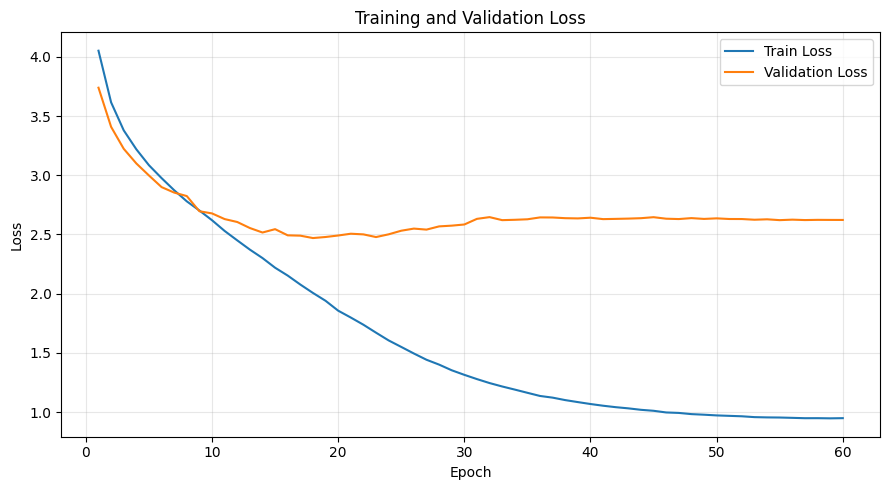

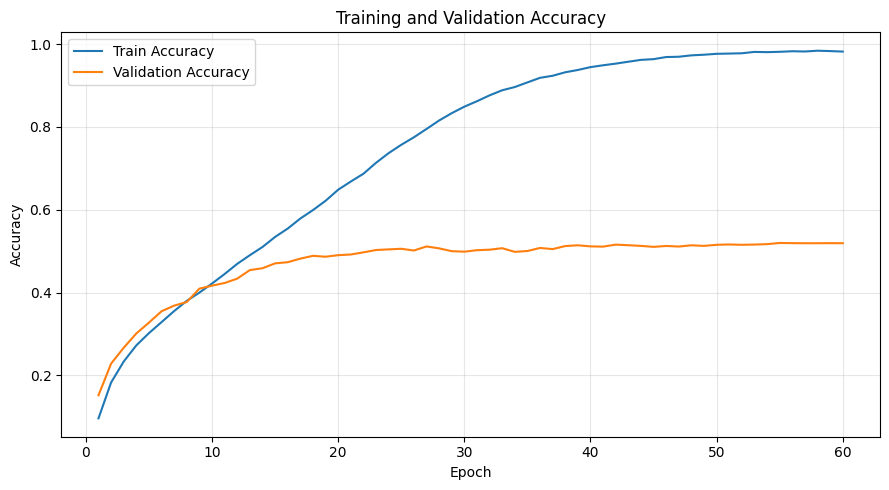

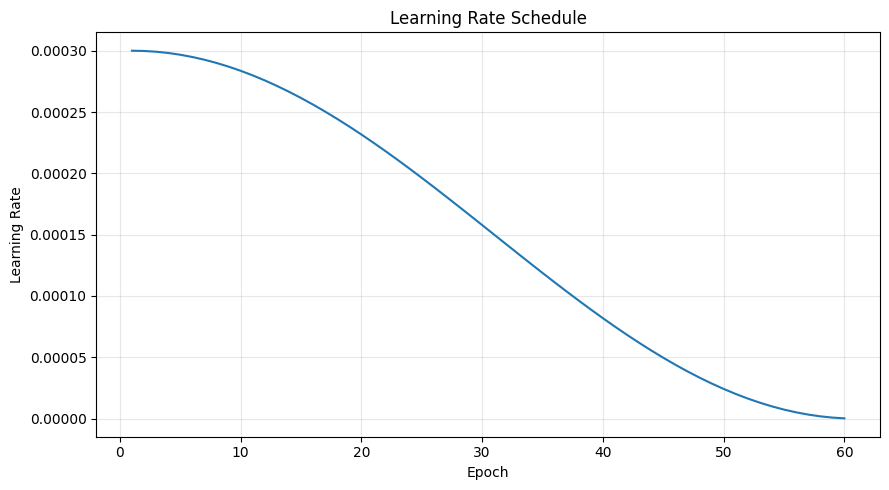

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["train_loss"], label="Train Loss")
ax.plot(history_df.index, history_df["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["train_accuracy"], label="Train Accuracy")
ax.plot(history_df.index, history_df["val_accuracy"], label="Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training and Validation Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_df.index, history_df["learning_rate"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Load the Best Checkpoint
Restore the model state from the epoch that achieved the highest validation accuracy before final testing.

In [11]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Loaded checkpoint from epoch {best_epoch}")
print(f"Validation accuracy at best epoch: {best_val_accuracy:.4f}")


Loaded checkpoint from epoch 55
Validation accuracy at best epoch: 0.5198


## 12. Evaluate on the Test Set
Run the best checkpoint over the untouched test set and collect logits, predictions, and targets for detailed analysis.

In [12]:
test_loss, test_accuracy = run_epoch(model, test_loader)

all_test_targets = []
all_test_predictions = []
all_test_confidences = []

model.eval()
with torch.no_grad():
    for batch_images, batch_targets in tqdm(test_loader, leave=False):
        batch_images = batch_images.to(DEVICE, non_blocking=True)
        logits = model(batch_images)
        probabilities = F.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)
        all_test_targets.extend(batch_targets.numpy())
        all_test_predictions.extend(predictions.cpu().numpy())
        all_test_confidences.extend(confidences.cpu().numpy())

all_test_targets = np.array(all_test_targets)
all_test_predictions = np.array(all_test_predictions)
all_test_confidences = np.array(all_test_confidences)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Test loss: 2.5772
Test accuracy: 0.5225


## 13. Summarize Classification Metrics
Calculate accuracy, macro precision, macro recall, macro F1, and weighted F1 on the full test set.

In [13]:
test_precision = precision_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_recall = recall_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_macro_f1 = f1_score(all_test_targets, all_test_predictions, average="macro", zero_division=0)
test_weighted_f1 = f1_score(all_test_targets, all_test_predictions, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Test Macro Precision",
        "Test Macro Recall",
        "Test Macro F1",
        "Test Weighted F1"
    ],
    "Value": [
        test_loss,
        test_accuracy,
        test_precision,
        test_recall,
        test_macro_f1,
        test_weighted_f1
    ]
})

print(metrics_df.to_string(index=False))


              Metric    Value
           Test Loss 2.577207
       Test Accuracy 0.522500
Test Macro Precision 0.519564
   Test Macro Recall 0.522400
       Test Macro F1 0.519214
    Test Weighted F1 0.519214


## 14. Analyze Class-wise Performance
Use the classification report to identify the strongest and weakest CIFAR-100 classes by F1 score.

In [14]:
report = classification_report(
    all_test_targets,
    all_test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

class_report_df = pd.DataFrame(report).T
class_report_df = class_report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
class_report_df = class_report_df.sort_values("f1-score", ascending=False)

print("Top 10 classes by F1 score")
print(class_report_df.head(10).to_string())
print("\nBottom 10 classes by F1 score")
print(class_report_df.tail(10).sort_values("f1-score").to_string())


Top 10 classes by F1 score
            precision  recall  f1-score  support
plain        0.805825    0.83  0.817734    100.0
sunflower    0.783019    0.83  0.805825    100.0
orange       0.710744    0.86  0.778281    100.0
lawn_mower   0.772277    0.78  0.776119    100.0
apple        0.732143    0.82  0.773585    100.0
motorcycle   0.762376    0.77  0.766169    100.0
road         0.723214    0.81  0.764151    100.0
cockroach    0.770833    0.74  0.755102    100.0
sea          0.697248    0.76  0.727273    100.0
skyscraper   0.715686    0.73  0.722772    100.0

Bottom 10 classes by F1 score
          precision  recall  f1-score  support
bowl       0.222222    0.18  0.198895    100.0
lizard     0.218391    0.19  0.203209    100.0
seal       0.290698    0.25  0.268817    100.0
otter      0.243902    0.30  0.269058    100.0
couch      0.308511    0.29  0.298969    100.0
woman      0.325581    0.28  0.301075    100.0
possum     0.333333    0.29  0.310160    100.0
squirrel   0.313725    0.32

## 15. Plot the Confusion Matrix
Visualize normalized class confusion to inspect systematic errors across the 100 CIFAR-100 categories.

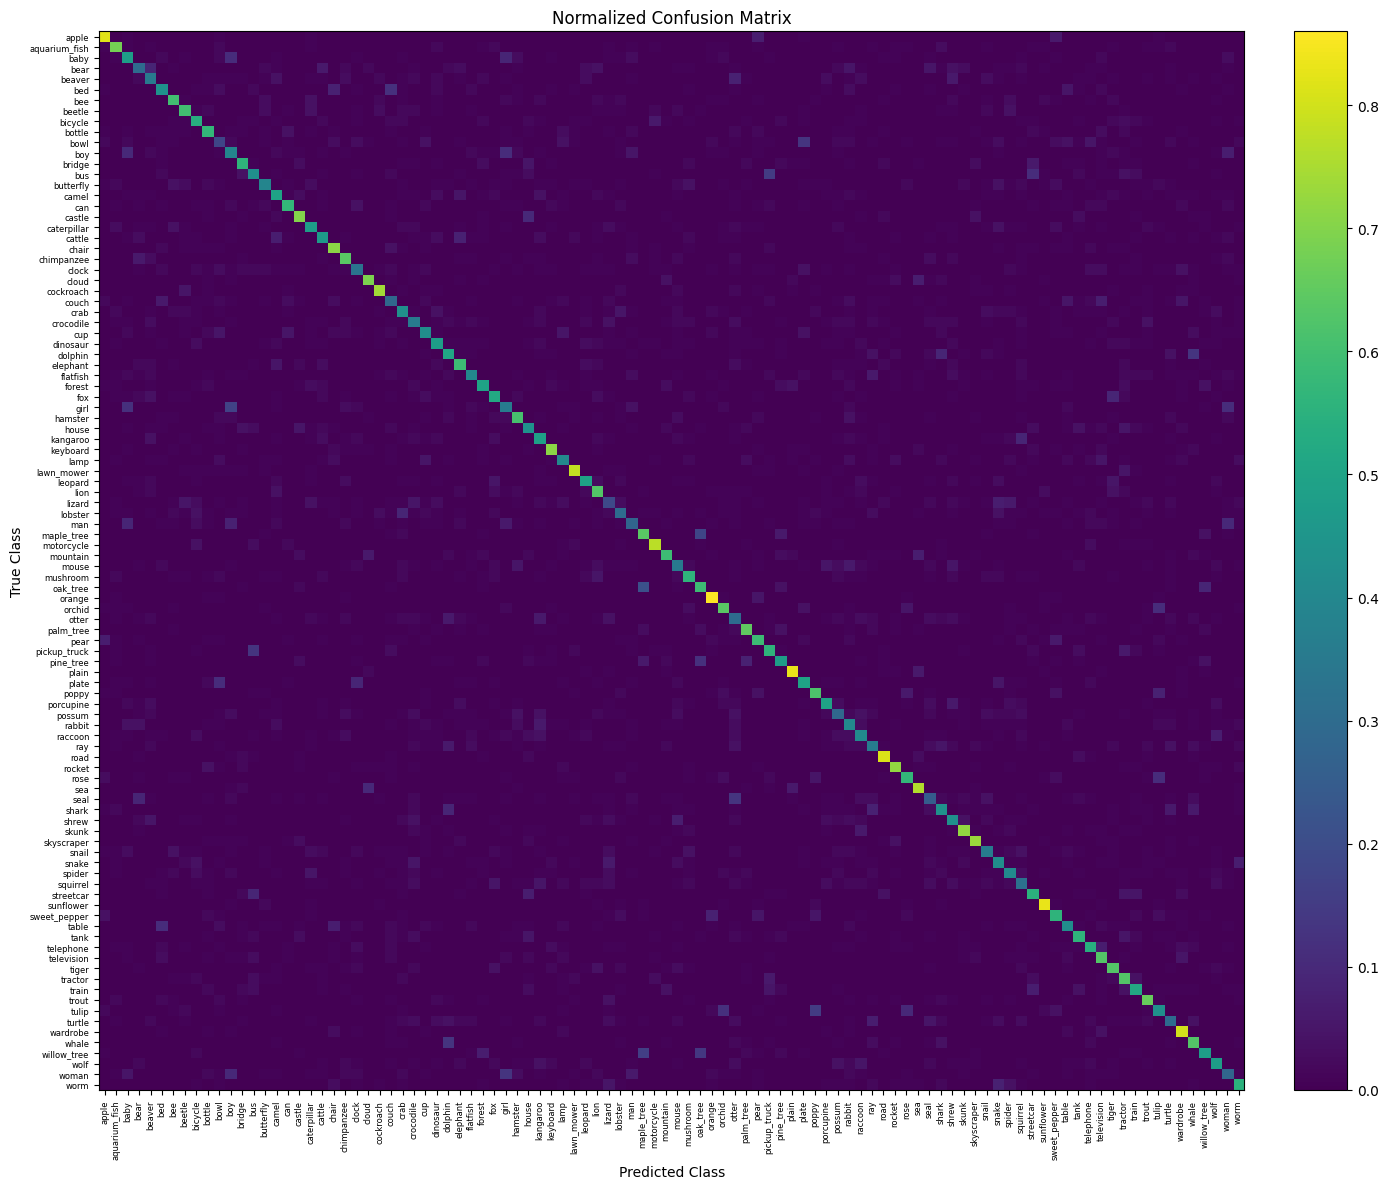

In [15]:
cm = confusion_matrix(all_test_targets, all_test_predictions, normalize="true")
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, interpolation="nearest", aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90, fontsize=6)
ax.set_yticklabels(class_names, fontsize=6)
plt.tight_layout()
plt.show()


## 16. Select Test Images
Choose a reproducible sample of correctly and incorrectly classified test images for visual prediction analysis.

In [16]:
rng = np.random.default_rng(SEED)
all_indices = np.arange(len(test_dataset))
correct_indices = all_indices[all_test_predictions == all_test_targets]
incorrect_indices = all_indices[all_test_predictions != all_test_targets]

sample_correct = rng.choice(correct_indices, size=min(6, len(correct_indices)), replace=False)
sample_incorrect = rng.choice(incorrect_indices, size=min(6, len(incorrect_indices)), replace=False) if len(incorrect_indices) else np.array([], dtype=int)
sample_indices = np.concatenate([sample_correct, sample_incorrect])

print(f"Correct test predictions: {len(correct_indices)}")
print(f"Incorrect test predictions: {len(incorrect_indices)}")
print(f"Selected images: {len(sample_indices)}")


Correct test predictions: 5224
Incorrect test predictions: 4776
Selected images: 12


## 17. Run Sample Predictions
Generate class probabilities, predicted labels, true labels, and confidence scores for the selected test images.

In [17]:
sample_images = []
sample_true = []
sample_pred = []
sample_conf = []

model.eval()
with torch.no_grad():
    for index in sample_indices:
        image, target = test_dataset[index]
        logits = model(image.unsqueeze(0).to(DEVICE))
        probabilities = F.softmax(logits, dim=1)
        confidence, prediction = probabilities.max(dim=1)
        sample_images.append(image)
        sample_true.append(target)
        sample_pred.append(prediction.item())
        sample_conf.append(confidence.item())

print(pd.DataFrame({
    "Index": sample_indices,
    "True Label": [class_names[i] for i in sample_true],
    "Predicted Label": [class_names[i] for i in sample_pred],
    "Confidence": sample_conf
}).to_string(index=False))


 Index True Label Predicted Label  Confidence
  6604     orchid          orchid    0.742113
  7753    hamster         hamster    0.626670
  4356        ray             ray    0.605747
  8595       rose            rose    0.914488
  4404    tractor         tractor    0.929918
   942      poppy           poppy    0.310099
  7583     bridge           house    0.741187
  5085  butterfly        squirrel    0.580802
  7142     turtle       crocodile    0.290104
  7320       tank            girl    0.279318
  7845 skyscraper          bridge    0.246474
  9742   keyboard             bee    0.265065


## 18. Visualize Predictions
Display the selected images with predicted labels, true labels, and confidence values.

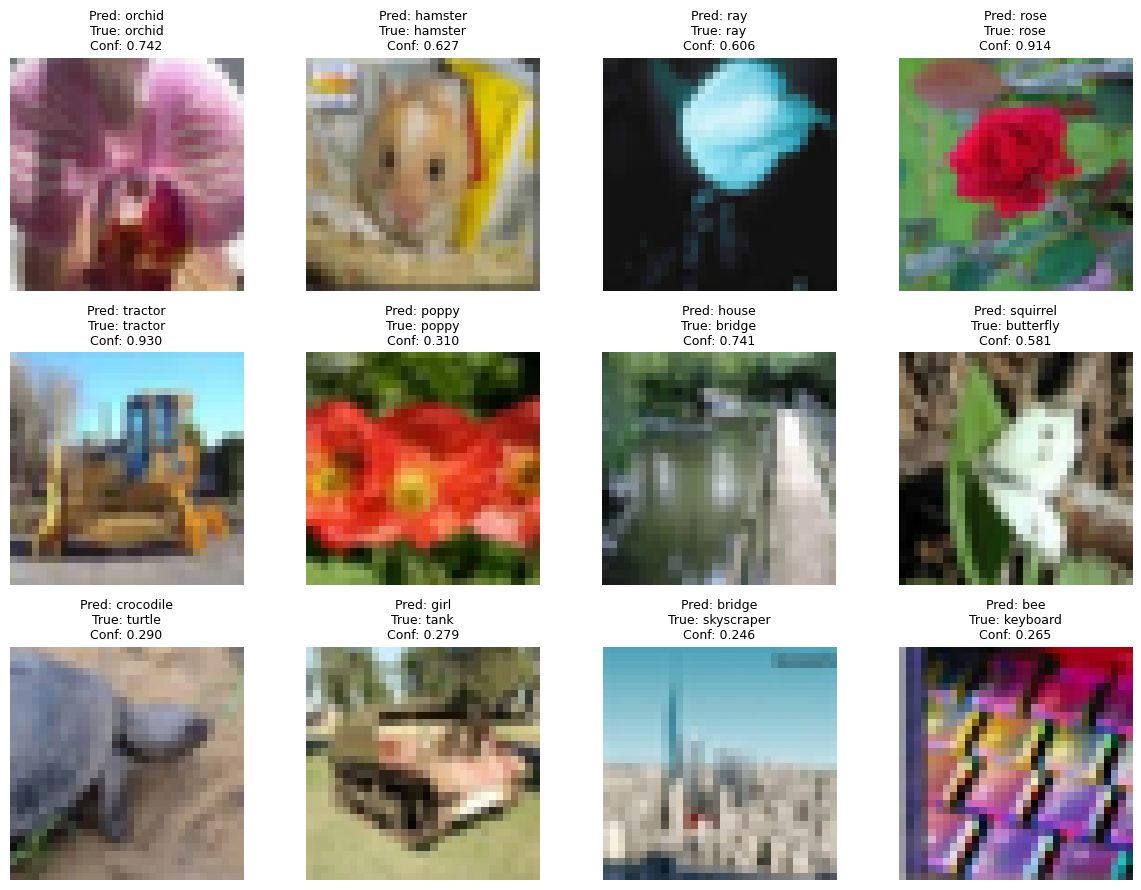

In [18]:
plot_mean = torch.tensor((0.5071, 0.4867, 0.4408)).view(3, 1, 1)
plot_std = torch.tensor((0.2675, 0.2565, 0.2761)).view(3, 1, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        image = (sample_images[i].cpu() * plot_std + plot_mean).clamp(0, 1)
        is_correct = sample_true[i] == sample_pred[i]
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(
            f"Pred: {class_names[sample_pred[i]]}\nTrue: {class_names[sample_true[i]]}\nConf: {sample_conf[i]:.3f}",
            fontsize=9
        )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 19. Inspect Prediction Confidence
Summarize the confidence distribution and compare confidence between correct and incorrect test predictions.

    Group  Mean Confidence  Median Confidence  Minimum Confidence  Maximum Confidence
      All         0.604091           0.610982            0.058222            0.998808
  Correct         0.752246           0.852710            0.085003            0.998808
Incorrect         0.442039           0.395457            0.058222            0.993358


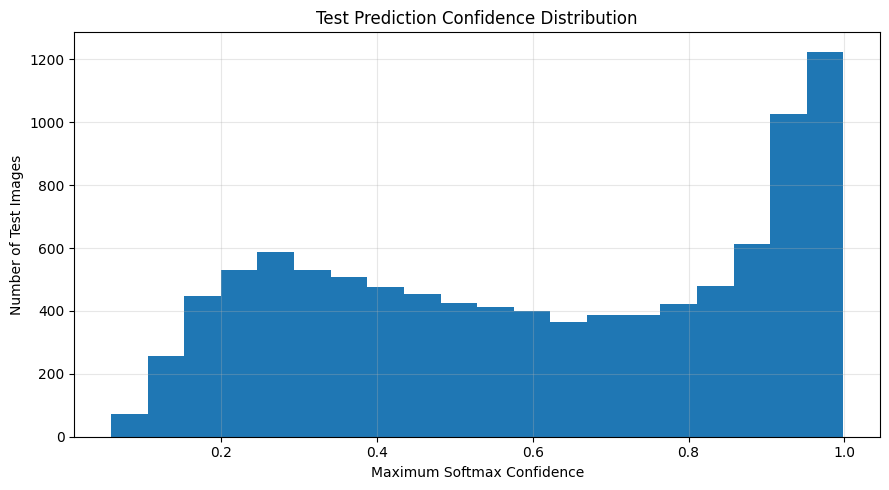

In [19]:
correct_mask = all_test_predictions == all_test_targets
incorrect_mask = ~correct_mask

confidence_summary = pd.DataFrame({
    "Group": ["All", "Correct", "Incorrect"],
    "Mean Confidence": [
        all_test_confidences.mean(),
        all_test_confidences[correct_mask].mean() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].mean() if incorrect_mask.any() else np.nan
    ],
    "Median Confidence": [
        np.median(all_test_confidences),
        np.median(all_test_confidences[correct_mask]) if correct_mask.any() else np.nan,
        np.median(all_test_confidences[incorrect_mask]) if incorrect_mask.any() else np.nan
    ],
    "Minimum Confidence": [
        all_test_confidences.min(),
        all_test_confidences[correct_mask].min() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].min() if incorrect_mask.any() else np.nan
    ],
    "Maximum Confidence": [
        all_test_confidences.max(),
        all_test_confidences[correct_mask].max() if correct_mask.any() else np.nan,
        all_test_confidences[incorrect_mask].max() if incorrect_mask.any() else np.nan
    ]
})
print(confidence_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(all_test_confidences, bins=20)
ax.set_xlabel("Maximum Softmax Confidence")
ax.set_ylabel("Number of Test Images")
ax.set_title("Test Prediction Confidence Distribution")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 20. Key Findings


## 21. Conclusion
